# How wrong can the cost assumption be before the strategy stops working?

**Docker image**: `ml4t`

## Purpose
A backtest's cost assumption is a guess. Commission schedules are knowable, but the spread paid
on a real order, and the price move caused by the order itself, are not knowable in advance and
vary with size and with the market. So the useful question is not "what does this strategy earn
net of costs" but "how far off can the guess be before the answer changes".

This notebook answers that for the ETF momentum baseline built in `01_backtest_first_principles`.
The universe, the protocol and the simulator are unchanged; the only thing that varies is the fee
charged per traded leg. Two numbers come out of it: the cost at which the strategy earns nothing,
and the multiplier that converts any fee into an annual drag.

## Learning objectives

- Re-simulate one strategy across a range of cost assumptions and read the resulting curve rather
  than a single net figure.
- Find the cost at which the strategy's growth rate reaches zero, and say what that number does
  and does not bound.
- Measure how much the strategy trades per year, and use it to estimate the annual cost of any
  fee without re-running anything.
- Reconcile the exact simulator result against that estimate, and account for the difference.

## Book reference
Chapter 16, Section 16.6 (diagnosing economic value).

## Prerequisites

- `01_backtest_first_principles`, which builds the strategy. The helper `_etf_baseline.py`
  reproduces its weights and returns so this notebook does not restate them.

In [1]:
"""How far the cost assumption can be wrong before the ETF momentum baseline stops working."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from _etf_baseline import (
    DEFAULT_FEES,
    INITIAL_CASH,
    annualized_turnover,
    break_even_cost_bp,
    load_panel,
    metrics,
    momentum_weights,
    simulate,
)
from ml4t.diagnostic.visualization.backtest.cost_attribution import plot_cost_sensitivity

from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
# Production defaults - Papermill injects overrides for CI
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
COST_GRID_BP = [0, 1, 2, 5, 10, 15, 25, 40, 60, 100, 150, 200]

### What each setting decides

**Cost grid.** The per-leg fees the strategy is re-simulated at, in basis points of traded
notional. It starts at zero, so the sweep contains the gross case, and runs far past anything a
retail account would pay, so it also contains the point where the strategy earns nothing. The
spacing is deliberately uneven: close together where the curve is steep near realistic fees,
wide apart out in the tail where only the crossing matters.

## 1. Build the strategy once, simulate it many times

The weights do not depend on the fee. This strategy ranks funds on their own price history and
rebalances on a fixed schedule, so it picks the same ETFs in the same months whether trading is
free or ruinous. That is what makes the sweep clean: the weights are built once and handed to the
simulator at each cost, so the only thing that changes between runs is the money paid to trade.

It is also an assumption worth naming. A strategy that sized positions by expected net return, or
that skipped trades below a cost threshold, would change its behaviour as fees rose, and its
sensitivity curve would be flatter than this one for a reason that has nothing to do with the
edge.

In [3]:
panel = load_panel(START_DATE, END_DATE)
weights = momentum_weights(panel)

result_gross = simulate(panel, weights, fees=0.0)
turnover_2way = annualized_turnover(result_gross)
gross = metrics(result_gross)
print(
    f"Gross (zero-cost): CAGR={gross['cagr'] * 100:.2f}%  "
    f"Sharpe={gross['sharpe']:.2f}  MaxDD={gross['max_drawdown'] * 100:.1f}%"
)
print(f"Annualized 2-way turnover: {turnover_2way * 100:.0f}% (sum |trades| / mean equity / years)")

Gross (zero-cost): CAGR=8.36%  Sharpe=0.77  MaxDD=-31.2%
Annualized 2-way turnover: 467% (sum |trades| / mean equity / years)


## 2. Re-simulate at every cost

Each row is a complete run of the same strategy at a different fee, scored on the same metrics.
The row at the baseline's own fee reproduces `01_backtest_first_principles` to the cent, which is
what `tests/test_etf_baseline_parity.py` asserts: the helper the diagnostics import is that
notebook's simulator, ported rather than reimplemented.

In [4]:
rows = []
results_by_cost = {}
for bp in COST_GRID_BP:
    res = simulate(panel, weights, fees=bp / 10_000)
    results_by_cost[bp] = res
    m = metrics(res)
    rows.append(
        {
            "cost_bp_per_leg": bp,
            "cagr": m["cagr"],
            "vol": m["vol"],
            "sharpe": m["sharpe"],
            "max_dd": m["max_drawdown"],
            "total_return": m["total_return"],
        }
    )
sweep = pd.DataFrame(rows)
sweep

,cost_bp_per_leg,cagr,vol,sharpe,max_dd,total_return
0,0,0.083632,0.113368,0.765372,-0.311961,2.072678
1,1,0.083092,0.113366,0.760983,-0.312255,2.051342
2,2,0.082552,0.113365,0.756592,-0.312549,2.030155
3,5,0.080935,0.113363,0.743407,-0.313429,1.967490
4,10,0.078246,0.113369,0.721396,-0.314893,1.865963
5,15,0.075565,0.113386,0.699345,-0.316353,1.767963
6,25,0.070228,0.113452,0.655147,-0.319264,1.582046
7,40,0.062281,0.113629,0.588698,-0.323605,1.326620
8,60,0.051792,0.114010,0.500063,-0.329347,1.025336
9,100,0.031168,0.115257,0.324061,-0.340674,0.535651


## 3. The cost at which the strategy earns nothing

Two ways to get there, and they disagree, which is the point of showing both.

The first divides the gross growth rate by the annual turnover: if the strategy earns some
percent a year and turns over its book some number of times, the fee that consumes the whole
return is the ratio. It is one line and it ignores compounding.

The second interpolates the simulator's own growth-rate curve between the last cost with a
positive result and the first without. That keeps the answer tied to the runs plotted below, and
it accounts for the fact that a fee paid early reduces the capital available to earn later.

Neither is a target. Both are ceilings, and a ceiling computed on one sample.

In [5]:
assert sweep["cagr"].is_monotonic_decreasing, "the sweep must fall monotonically in cost"
assert (sweep["cagr"] <= 0).any(), "extend COST_GRID_BP until the growth rate turns negative"

positive = sweep.loc[sweep["cagr"] > 0].iloc[-1]
negative = sweep.loc[sweep["cagr"] <= 0].iloc[0]
break_even_bp = positive["cost_bp_per_leg"] + (0 - positive["cagr"]) * (
    negative["cost_bp_per_leg"] - positive["cost_bp_per_leg"]
) / (negative["cagr"] - positive["cagr"])
linear_break_even_bp = break_even_cost_bp(result_gross)

print(f"Baseline fee:                          {DEFAULT_FEES * 10_000:.0f} bp per leg")
print(f"Break-even, growth rate over turnover: {linear_break_even_bp:.0f} bp per leg")
print(f"Break-even, simulator interpolation:   {break_even_bp:.0f} bp per leg")
print(f"Headroom over the baseline fee:        {break_even_bp / (DEFAULT_FEES * 10_000):.0f}x")

Baseline fee:                          5 bp per leg
Break-even, growth rate over turnover: 179 bp per leg
Break-even, simulator interpolation:   162 bp per leg
Headroom over the baseline fee:        32x


The gap between the two estimates is compounding. The linear one assumes the fee is a flat
deduction from the growth rate; the simulator knows that money paid in fees in the first year is
money not compounding for the next thirteen, so it reaches zero sooner. On a long sample the
difference is not small.

A large headroom figure is reassuring only for the thing it measures. Three limits on it:

The fee here is the whole cost. A real order also pays the spread and moves the price against
itself, and neither is in this number. What the sweep bounds is total round-trip cost, so a
reader comparing it against a commission schedule alone is comparing the wrong quantities.

The average is doing a lot of work. A strategy that traded heavily in the years that produced its
return, and lightly otherwise, is more fragile than its average turnover suggests, and this
diagnostic cannot see the difference.

And the crossing is a property of this sample. A period in which the strategy earned less would
put it closer to the fee actually paid.

## 4. The curve

Both panels put per-leg cost on the horizontal axis. What to read off them is the *slope* at the
baseline fee, not the level: it says how much of the result a small error in the cost estimate
would move. A steep curve there means the backtest's conclusion depends on getting the fee right;
a flat one means it does not.

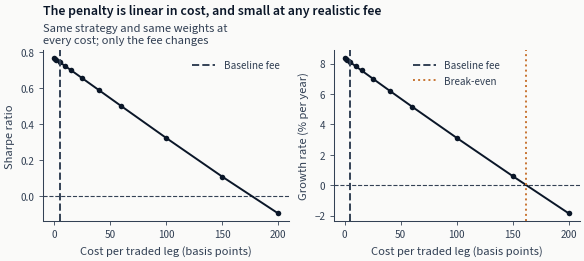

In [6]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h"], constrained_layout=True)

for ax, series, label in (
    (axes[0], sweep["sharpe"], "Sharpe ratio"),
    (axes[1], sweep["cagr"] * 100, "Growth rate (% per year)"),
):
    ax.plot(sweep["cost_bp_per_leg"], series, color=COLORS["blue"], marker="o")
    ax.axvline(DEFAULT_FEES * 10_000, color=COLORS["neutral"], linestyle="--", label="Baseline fee")
    zero_line(ax)
    ax.set_xlabel("Cost per traded leg (basis points)")
    ax.set_ylabel(label)

axes[1].axvline(break_even_bp, color=COLORS["copper"], linestyle=":", label="Break-even")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)

add_message_title(
    axes[0],
    "The penalty is linear in cost, and small at any realistic fee",
    subtitle="Same strategy and same weights at every cost; only the fee changes",
)
fig.show()

## 5. Turnover as the multiplier

Once the turnover is known, the annual cost of any fee can be read without re-running anything:

$$\text{annual drag} \approx \text{annual turnover} \times \text{fee per leg}.$$

That is the number worth carrying in your head when someone quotes a commission schedule. The
comparison below checks it against what the simulator actually charged, which is the only way to
know whether the approximation is good enough to rely on.

In [7]:
fee_bp = DEFAULT_FEES * 10_000
estimated_drag_pct = turnover_2way * DEFAULT_FEES * 100
realized_drag_pct = (
    gross["cagr"] - sweep.loc[sweep["cost_bp_per_leg"] == fee_bp, "cagr"].iloc[0]
) * 100
print(f"Annual turnover:                     {turnover_2way:.2f}x")
print(f"Estimated drag at {fee_bp:.0f} bp per leg:      {estimated_drag_pct:.2f}% per year")
print(f"Drag the simulator actually charged: {realized_drag_pct:.2f}% per year")

Annual turnover:                     4.67x
Estimated drag at 5 bp per leg:      0.23% per year
Drag the simulator actually charged: 0.27% per year


The estimate is close and slightly low, for the same reason the linear break-even was high:
multiplying turnover by the fee counts the money paid out and stops there, while the simulator
also loses whatever that money would have earned had it stayed invested. Over a long sample the
second part is not negligible, and it always runs in the same direction.

## 6. Where the money went, and the same view from the library

The waterfall below accounts for the whole gross-to-net gap in dollars rather than in percentage
points, and it separates the two components section 5 just discussed: the fees themselves, and
the return those fees would have earned. The assertion is the check that nothing is unaccounted
for.

After it, the same sensitivity curve from `ml4t-diagnostic`, which computes the drag from the
gross return series rather than by re-simulating. It is one call instead of a loop, and it is an
approximation - the comparison printed with it is how much of one.

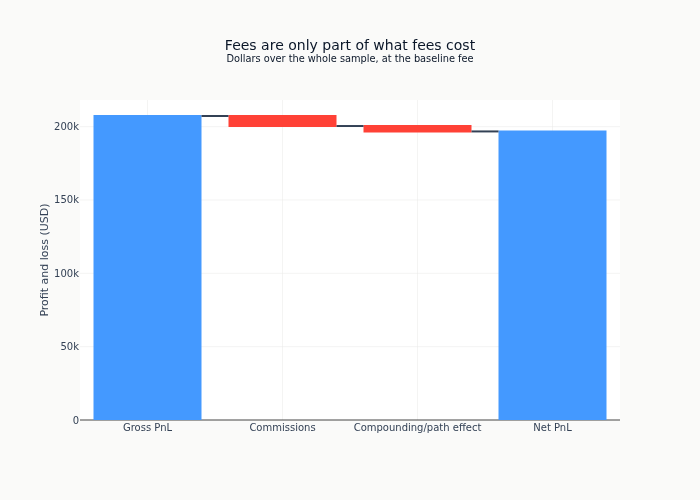

In [8]:
result_net = results_by_cost[fee_bp]
# From INITIAL_CASH, not from each run's first CLOSING equity: that first close already
# contains a session's return and, in the net run, the opening commission, so measuring
# from it gives the two runs different bases and drops the difference into
# path_effect_dollars, which is the reconciling residual and so cannot report it.
gross_pnl_dollars = float(result_gross.equity.iloc[-1]) - INITIAL_CASH
net_pnl_dollars = float(result_net.equity.iloc[-1]) - INITIAL_CASH
commission_dollars = float((result_net.trades_dollar * DEFAULT_FEES).sum())
path_effect_dollars = gross_pnl_dollars - commission_dollars - net_pnl_dollars
assert np.isclose(gross_pnl_dollars - commission_dollars - path_effect_dollars, net_pnl_dollars)

waterfall = go.Figure(
    go.Waterfall(
        measure=["absolute", "relative", "relative", "total"],
        x=["Gross PnL", "Commissions", "Compounding/path effect", "Net PnL"],
        y=[gross_pnl_dollars, -commission_dollars, -path_effect_dollars, net_pnl_dollars],
        connector={"line": {"color": COLORS["neutral"]}},
    )
)
waterfall.update_layout(
    title=(
        "Fees are only part of what fees cost"
        "<br><sup>Dollars over the whole sample, at the baseline fee</sup>"
    ),
    yaxis_title="Profit and loss (USD)",
    showlegend=False,
)
waterfall.show()

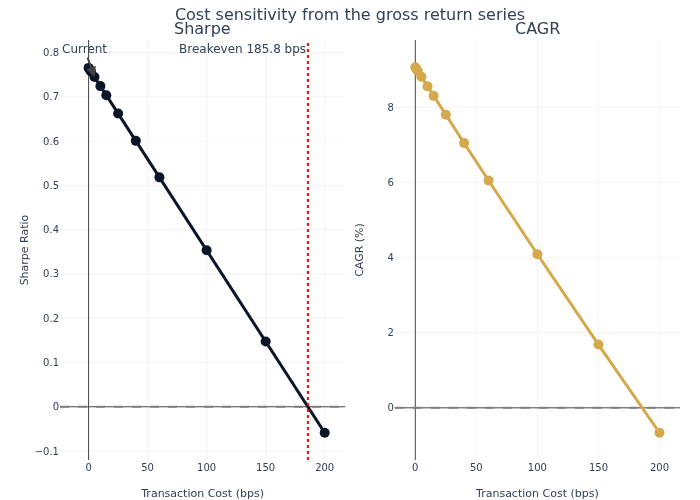

In [9]:
gross_returns_pl = pl.from_pandas(result_gross.returns.rename("returns").reset_index()).get_column(
    "returns"
)
sensitivity = plot_cost_sensitivity(
    returns=gross_returns_pl,
    base_costs_bps=DEFAULT_FEES * 10_000,
    # The parameter is named for a trade count, and what the drag calculation needs is turnover:
    # dollars traded per dollar of capital per year. That is what is passed.
    trades_per_year=float(turnover_2way),
    cost_multipliers=[bp / (DEFAULT_FEES * 10_000) for bp in COST_GRID_BP],
    title="Cost sensitivity from the gross return series",
)
sensitivity.show()

The library figure has the same shape and does not have the same zero crossing, because it
deducts a uniform daily drag from the gross return series instead of re-simulating. Which one to
quote depends on what the number is for: the library call is the right thing to put in a
production report bundle beside everything else `09_performance_reporting` assembles, and the
sweep in section 2 is the right thing to quote a break-even from, because it is the one that
actually ran the strategy at each fee.

## Key takeaways

1. **A net Sharpe is one point on a curve, and the curve is the reportable thing.** A backtest
   that quotes a single net figure has hidden the one property a reader needs: whether the
   conclusion depends on the cost assumption being right.
2. **Turnover converts any fee into an annual drag, in one multiplication.** Measure it once and
   the cost of any commission schedule can be read off without re-running anything. It is also
   the number that says whether a break-even figure is comfortable: two strategies with the same
   gross return and a tenfold difference in turnover have a tenfold difference in headroom.
3. **The back-of-envelope estimate is biased in a known direction.** Multiplying turnover by the
   fee counts the money paid and stops. The simulator also loses what that money would have
   earned, so the true drag is larger and the true break-even is lower. Use the shortcut to
   reason quickly and the simulator to quote a number.
4. **A break-even cost bounds total round-trip cost, not commission.** Spread and market impact
   come out of the same allowance. Comparing the headroom against a broker's commission schedule
   alone reads it as far more comfortable than it is.
5. **This diagnostic cannot tell you a strategy works.** It says how sensitive an answer is to
   one assumption. Read it with the benchmark comparison and the regime split in
   `10_regime_backtest_analysis` before concluding anything about economic value.

### Known limitations

- The weights are fixed across the sweep, so the strategy never reacts to a higher fee by
  trading less. A real implementation would, which makes this curve steeper than a well-managed
  one and shallower than a naive one.
- Cost is a flat rate on notional. It does not grow with order size and does not depend on how
  much volume the market had, so nothing here bounds what a large account would pay. Chapter 18
  replaces the flat rate with a model that does.
- Everything is measured on one sample of one strategy on ten funds, and the break-even is a
  property of the returns that sample happened to produce.